In [ ]:
#revisando data
import pandas as pd
import numpy as np
# Ejecuta esto para diagnosticar
print("=== DIAGNÓSTICO DEL PIPELINE ===")

# 1. Revisar data_cleaned
df_cleaned = pd.read_parquet('../data/processed/data_cleaned.parquet')
print(f"data_cleaned: {df_cleaned.shape}")

# 2. Revisar data_processed  - usaremos para el entrenamiento
df_processed = pd.read_parquet('../data/processed/data_processed.parquet')
print(f"data_processed: {df_processed.shape}")

# 4. Revisar datos originales
df_raw = pd.read_csv('../data/raw/retail_store_sales.csv')
print(f"data_sample (raw): {df_raw.shape}")

=== DIAGNÓSTICO DEL PIPELINE ===
data_cleaned: (12575, 11)
data_processed: (12575, 33)
data_training: (12575, 12)
data_sample (raw): (12575, 11)


✅ Precisión del modelo: 63.50%



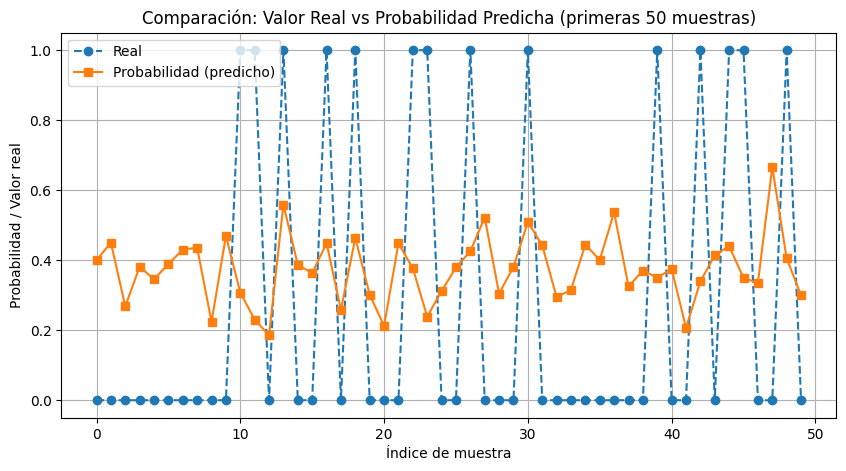

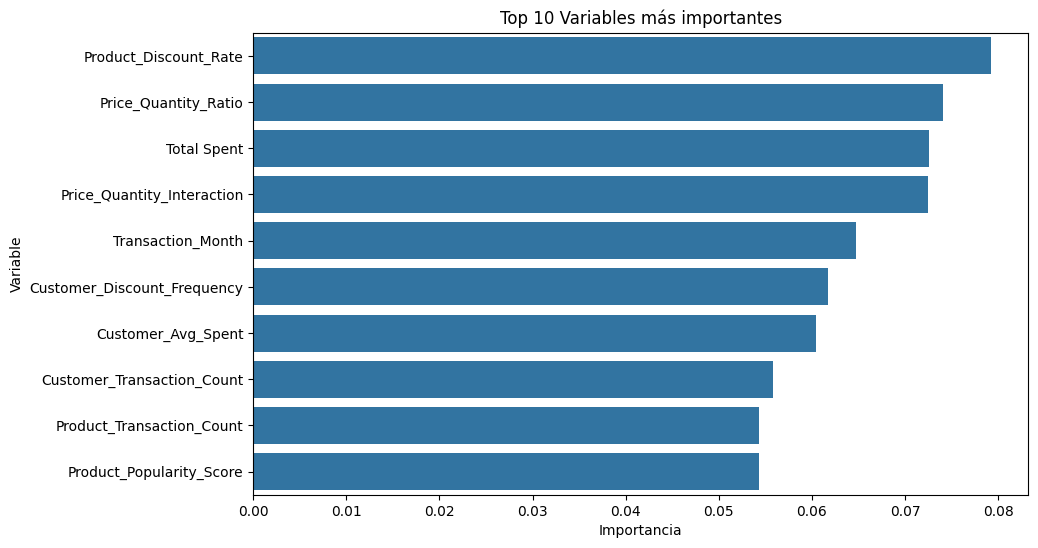

In [48]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Eliminar columnas no predictoras
X = df_processed.drop(['Discount Applied', 'Customer ID', 'Transaction Date'], axis=1)
y = df_processed['Discount Applied']

# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar variables numéricas (no afecta las categóricas ya codificadas)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. ENTRENAR MODELO RANDOM FOREST
# ==========================================
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# ==========================================
# 4. EVALUAR MODELO
# ==========================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Precisión del modelo: {accuracy*100:.2f}%\n")

# ==========================================
# 5. GRAFICAR PREDICCIONES (primeras 50 muestras)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Real', marker='o', linestyle='--')
plt.plot(y_prob[:50], label='Probabilidad (predicho)', marker='s')
plt.title("Comparación: Valor Real vs Probabilidad Predicha (primeras 50 muestras)")
plt.xlabel("Índice de muestra")
plt.ylabel("Probabilidad / Valor real")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 6. IMPORTANCIA DE VARIABLES
# ==========================================
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importances.head(10))
plt.title('Top 10 Variables más importantes')
plt.show()
